In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

Результат загрузки изображения:
Размер изображения: (225, 225)


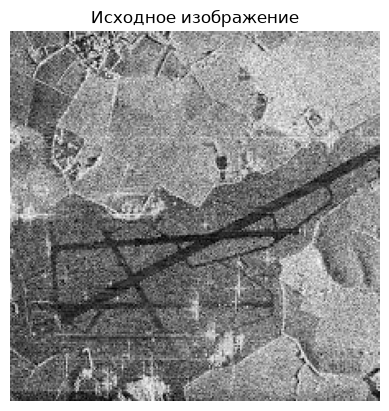

In [2]:
image_gray = cv2.imread('Desktop/sar_3.jpg', cv2.IMREAD_GRAYSCALE)

print('Результат загрузки изображения:')
print('Размер изображения:', image_gray.shape)

plt.imshow(image_gray, cmap='gray')
plt.title('Исходное изображение')
plt.axis('off')
plt.show()

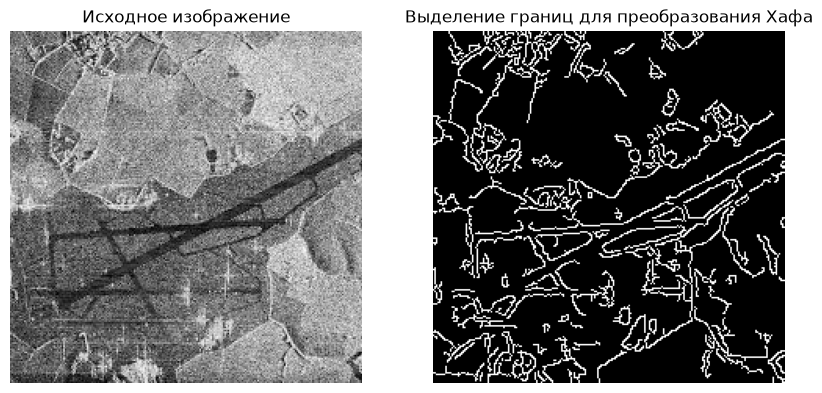

In [6]:
blurred = cv2.GaussianBlur(image_gray, (5, 5), 0)

edges = cv2.Canny(blurred, 80, 180)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_gray, cmap='gray')
plt.title('Исходное изображение')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(edges, cmap='gray')
plt.title('Выделение границ для преобразования Хафа')
plt.axis('off')

plt.show()

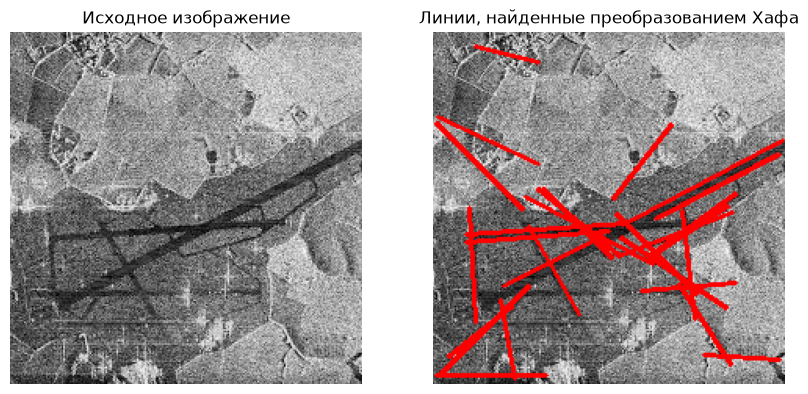

In [24]:
lines = cv2.HoughLinesP(
    edges,
    rho=1,
    theta=np.pi / 180,
    threshold=50,
    minLineLength=40,
    maxLineGap=10
)

hough_image = cv2.cvtColor(image_gray, cv2.COLOR_GRAY2RGB)

if lines is not None:
    lines = np.array(lines).reshape(-1, 4)

    for x1, y1, x2, y2 in lines:
        cv2.line(
            hough_image,
            (x1, y1),
            (x2, y2),
            (255, 0, 0),
            2
        )

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_gray, cmap='gray')
plt.title('Исходное изображение')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(hough_image)
plt.title('Линии, найденные преобразованием Хафа')
plt.axis('off')

plt.show()

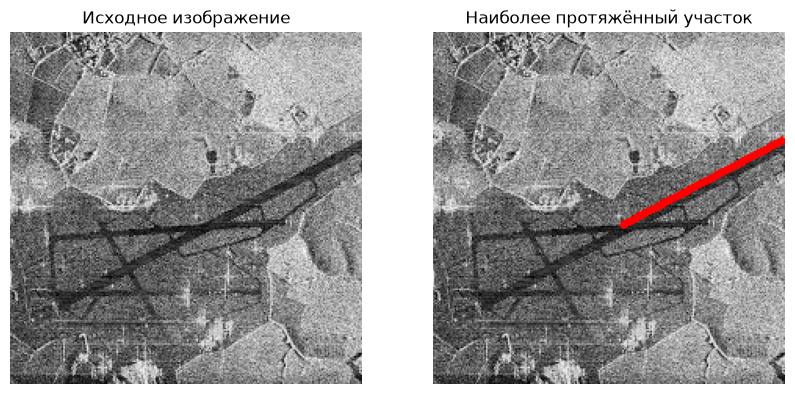

Длина наиболее протяжённого участка: 115.41 пикс.


In [11]:
lengths = np.sqrt(
    (lines[:, 2] - lines[:, 0])**2 +
    (lines[:, 3] - lines[:, 1])**2
)

longest_line = lines[np.argmax(lengths)]
x1, y1, x2, y2 = longest_line

longest_image = cv2.cvtColor(image_gray, cv2.COLOR_GRAY2RGB)

cv2.line(
    longest_image,
    (x1, y1),
    (x2, y2),
    (255, 0, 0),
    3
)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_gray, cmap='gray')
plt.title('Исходное изображение')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(longest_image)
plt.title('Наиболее протяжённый участок')
plt.axis('off')

plt.show()

print('Длина наиболее протяжённого участка:', round(np.max(lengths), 2), 'пикс.')

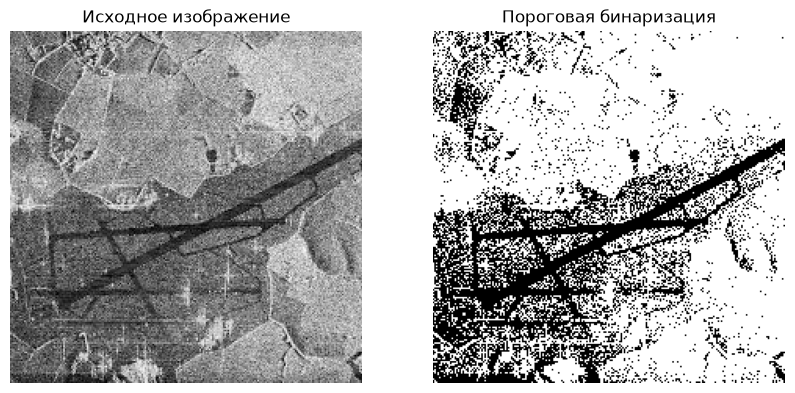

In [12]:
_, binary = cv2.threshold(
    image_gray,
    100,
    255,
    cv2.THRESH_BINARY
)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_gray, cmap='gray')
plt.title('Исходное изображение')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(binary, cmap='gray')
plt.title('Пороговая бинаризация')
plt.axis('off')

plt.show()

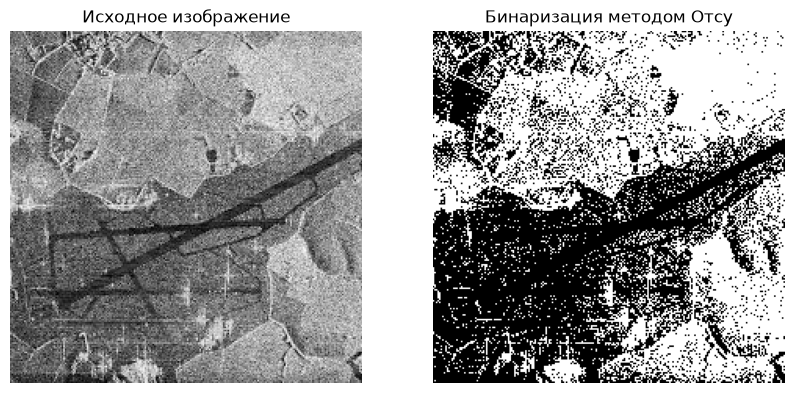

Порог, выбранный методом Отсу: 129.0


In [17]:
otsu_threshold, binary_otsu = cv2.threshold(
    image_gray,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_gray, cmap='gray')
plt.title('Исходное изображение')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(binary_otsu, cmap='gray')
plt.title('Бинаризация методом Отсу')
plt.axis('off')

plt.show()

print('Порог, выбранный методом Отсу:', otsu_threshold)

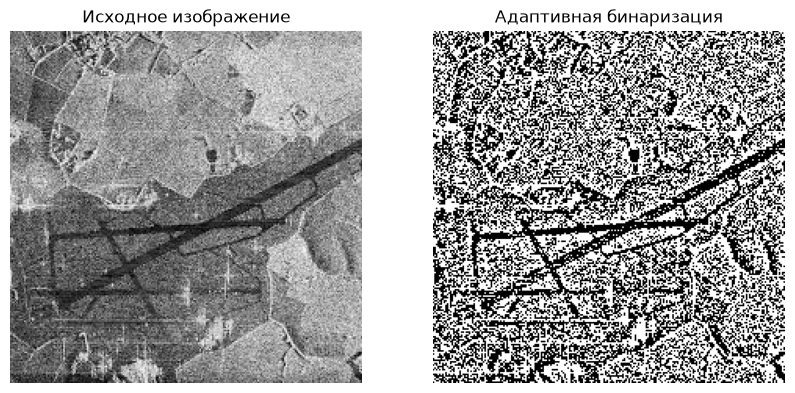

In [14]:
binary_adaptive = cv2.adaptiveThreshold(
    image_gray,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    21,
    5
)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_gray, cmap='gray')
plt.title('Исходное изображение')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(binary_adaptive, cmap='gray')
plt.title('Адаптивная бинаризация')
plt.axis('off')

plt.show()

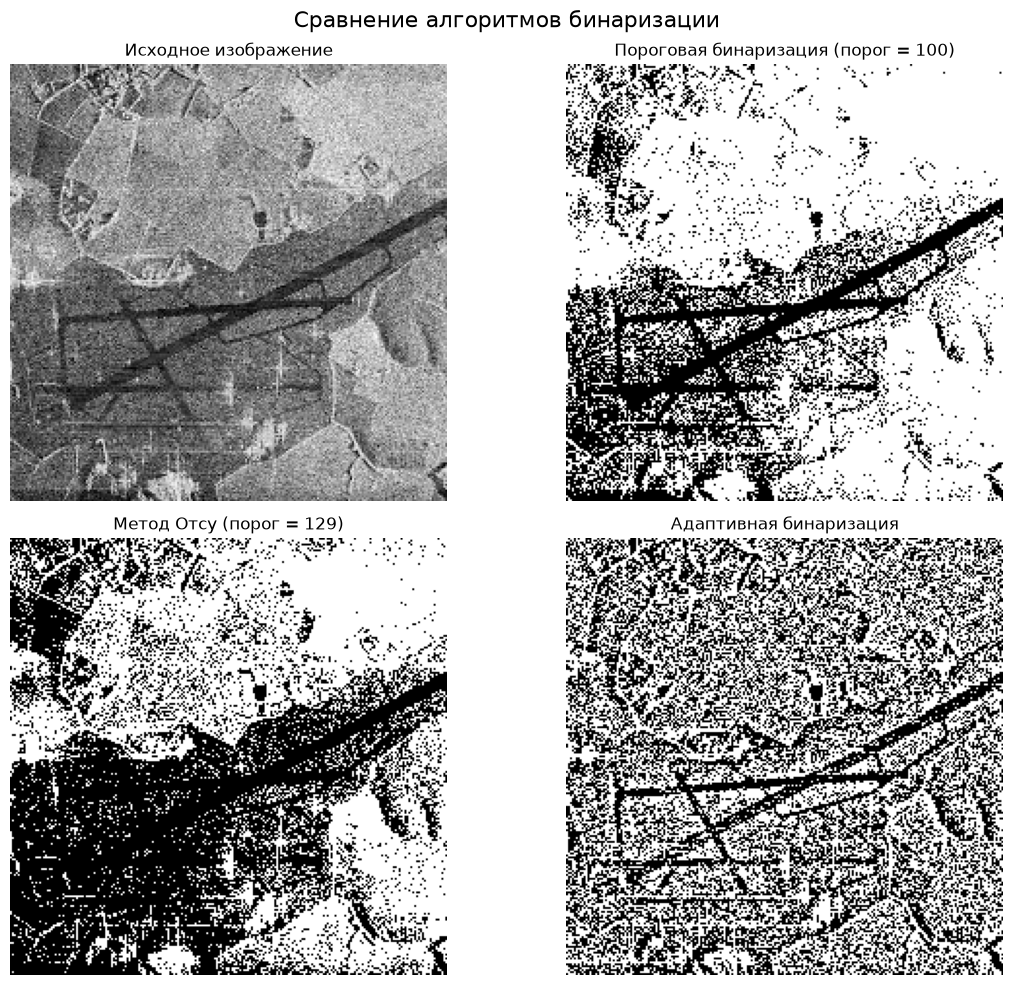

In [19]:
plt.figure(figsize=(12, 10))

plt.suptitle('Сравнение алгоритмов бинаризации', fontsize=16)

plt.subplot(2, 2, 1)
plt.imshow(image_gray, cmap='gray')
plt.title('Исходное изображение')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(binary, cmap='gray')
plt.title('Пороговая бинаризация (порог = 100)')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(binary_otsu, cmap='gray')
plt.title('Метод Отсу (порог = 129)')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(binary_adaptive, cmap='gray')
plt.title('Адаптивная бинаризация')
plt.axis('off')

plt.tight_layout()
plt.show()

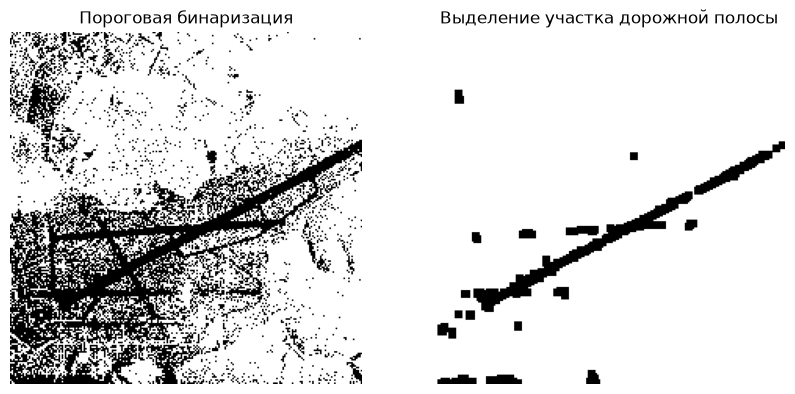

In [22]:
#Морфологическая обработка бинарного изображения чтобы выделить четко полосу
kernel = cv2.getStructuringElement(
    cv2.MORPH_RECT,
    (5, 5)
)

road_section = cv2.morphologyEx(
    binary,
    cv2.MORPH_CLOSE,
    kernel
)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(binary, cmap='gray')
plt.title('Пороговая бинаризация')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(road_section, cmap='gray')
plt.title('Выделение участка дорожной полосы')
plt.axis('off')

plt.show()

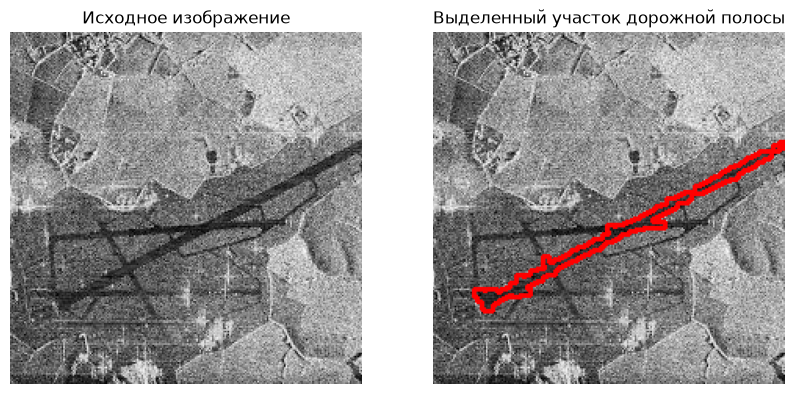

In [25]:
road_result = cv2.cvtColor(image_gray, cv2.COLOR_GRAY2RGB)

mask = cv2.bitwise_not(road_section)

contours, _ = cv2.findContours(
    mask,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

large_contours = [
    contour for contour in contours
    if cv2.contourArea(contour) > 100
]

cv2.drawContours(
    road_result,
    large_contours,
    -1,
    (255, 0, 0),
    2
)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_gray, cmap='gray')
plt.title('Исходное изображение')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(road_result)
plt.title('Выделенный участок дорожной полосы')
plt.axis('off')

plt.show()